In [ ]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1","cluster_a","cluster_b","cluster_c"]
load_list_dict = dict()
load_list_dict["unv1"] = range(1,11)
load_list_dict["prv1"] = range(1,11)
load_list_dict["cluster_a"] = range(3,31,3)
load_list_dict["cluster_b"] = range(4,41,4)
load_list_dict["cluster_c"] = range(5,51,5)
seed_list = [1,2,3,4,5]
scheme_list = ["dringsu2","dringsu2e","leafspine","rrgsu2","df2augalg","dringecmp","dringwcmpecmp","dringfatpaths","dringfhi","dringracke1four"]


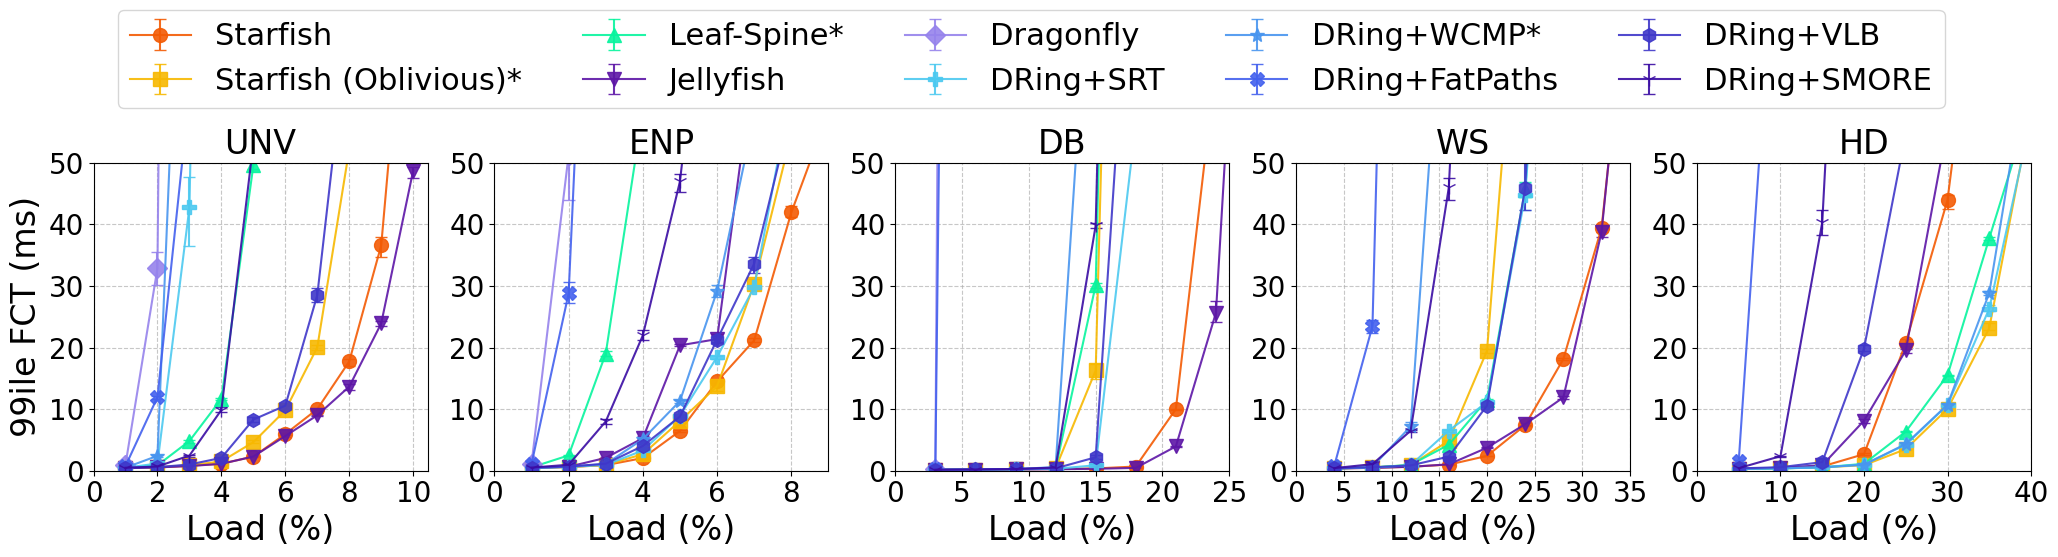

In [5]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)*","leafspine":"Leaf-Spine*","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+SRT","dringwcmpecmp":"DRing+WCMP*","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":None,"prv1":9,"cluster_a":25,"cluster_b":35,"cluster_c":40}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}
plotxticksdict = {"unv1":[0,2,4,6,8,10],"prv1":[0,2,4,6,8],"cluster_a":[0,5,10,15,20,25],"cluster_b":[0,5,10,15,20,25,30,35],"cluster_c":[0,10,20,30,40]}

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99


markerlist = ['o','x']
nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        for load in load_list_dict[cm]:
            fct_list_allseeds = list()
            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        if ic==0:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], alpha=0.9, markersize=10, marker=plotmarkers[isc], color=plotcolordict[scheme], capsize=4, label=plotlabeldict[scheme])
        else:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], alpha=0.9, markersize=10, marker=plotmarkers[isc], color=plotcolordict[scheme], capsize=4)

    axs[ic].set_xlabel("Load (%)", fontsize=24)
    if ic==0:
        axs[ic].set_ylabel("99ile FCT (ms)", fontsize=24)
    axs[ic].set_xlim(0,plotxlimdict[cm])
    axs[ic].set_ylim(0,50)
    axs[ic].set_xticks(plotxticksdict[cm])
    axs[ic].tick_params(axis='both', labelsize=20)
    axs[ic].set_title(plottitledict[cm], fontsize=24)
    axs[ic].grid(True, linestyle='--', alpha=0.7)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=5, fontsize=22)
plt.savefig(f"eval_main.pdf", dpi=600, bbox_inches='tight')

starfish: 9.2,8.4,23,32.6,30.4
starfish (oblivious): 8,7.8,15,21.6,39
leafspine: 4.8,3.8,15,24,38
vlb: 7.6,7.7,16.2,24,24.5
jellyfish: 10,6.6,24.6,32.6,29

In [2]:
s =  [9.2,8.4,23,32.6,30.4]
o = [8,7.8,15,21.6,39]
l = [4.8,3.8,15,24,38]
v = [7.6,7.7,16.2,24,24.5]
j = [10,6.6,24.6,32.6,29]

In [3]:
# starfish vs leafspine:
mysum = 0
for i in range(5):
    mysum += s[i]/l[i]
print(f"starfish vs leafspine: {mysum/5:.4f}")

# starfish (oblivious) vs leafspine:
mysum = 0
for i in range(5):
    mysum += o[i]/l[i]
print(f"starfish (oblivious) vs leafspine: {mysum/5:.4f}")

# starfish vs vlb:
mysum = 0
for i in range(5):
    mysum += s[i]/v[i]
print(f"starfish vs vlb: {mysum/5:.4f}")

# jellyfish vs leafspine:
mysum = 0
for i in range(5):
    mysum += j[i]/l[i]
print(f"jellyfish vs leafspine: {mysum/5:.4f}")

starfish vs leafspine: 1.5638
starfish (oblivious) vs leafspine: 1.3291
starfish vs vlb: 1.2641
jellyfish vs leafspine: 1.5163


In [2]:
(38-30.4)/38

0.20000000000000004

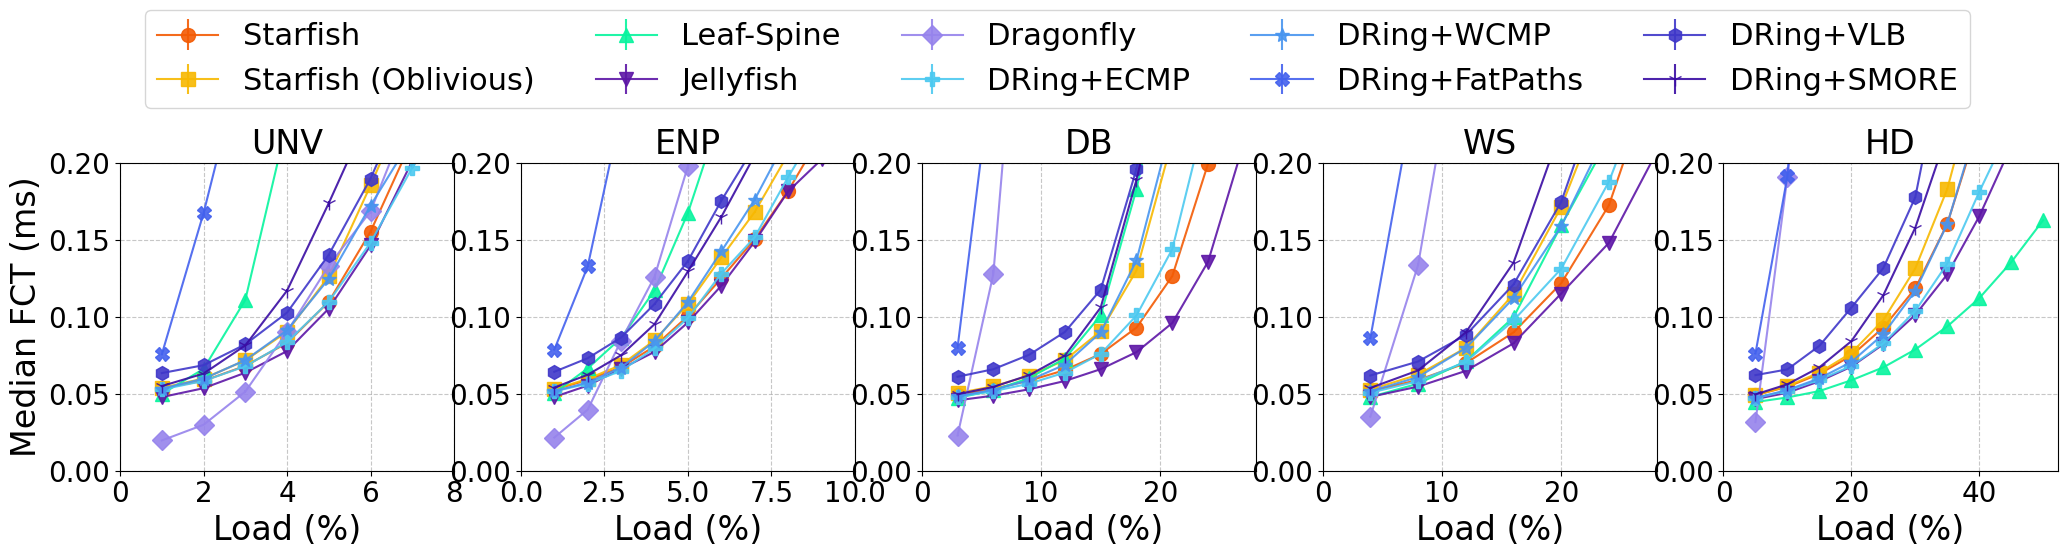

In [50]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)","leafspine":"Leaf-Spine","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+ECMP","dringwcmpecmp":"DRing+WCMP","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotxlimdict = {"unv1":8,"prv1":10,"cluster_a":28,"cluster_b":28,"cluster_c":None}
plotmarkers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '1']
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p50


markerlist = ['o','x']
nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):
    for isc,scheme in enumerate(scheme_list):
        fct_list = list()
        for load in load_list_dict[cm]:
            fct_list_allseeds = list()
            for seed in seed_list:
                outfile = f"{cm}/outfiles/{scheme}_load{load}_seed{seed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        if ic==0:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], alpha=0.9, markersize=10, marker=plotmarkers[isc], color=plotcolordict[scheme], label=plotlabeldict[scheme])
        else:
            axs[ic].errorbar(load_list_dict[cm], [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], alpha=0.9, markersize=10, marker=plotmarkers[isc], color=plotcolordict[scheme])

    axs[ic].set_xlabel("Load (%)", fontsize=24)
    if ic==0:
        axs[ic].set_ylabel("Median FCT (ms)", fontsize=24)
    axs[ic].set_xlim(0,plotxlimdict[cm])
    axs[ic].set_ylim(0,0.2)
    axs[ic].tick_params(axis='both', labelsize=20)
    axs[ic].set_title(plottitledict[cm], fontsize=24)
    axs[ic].grid(True, linestyle='--', alpha=0.7)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=5, fontsize=22)
plt.savefig(f"eval_main_p50.pdf", dpi=600, bbox_inches='tight')

In [2]:
import pickle

with open(f"{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_prv1.pickle", 'rb') as f:
    prv1datadict = pickle.load(f)

In [3]:
import pickle

with open(f"{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_unv1.pickle", 'rb') as f:
    unv1datadict = pickle.load(f)

In [18]:
import pickle

with open(f"{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_main_dringsu2e.pickle", 'rb') as f:
    dringsu2edatadict = pickle.load(f)

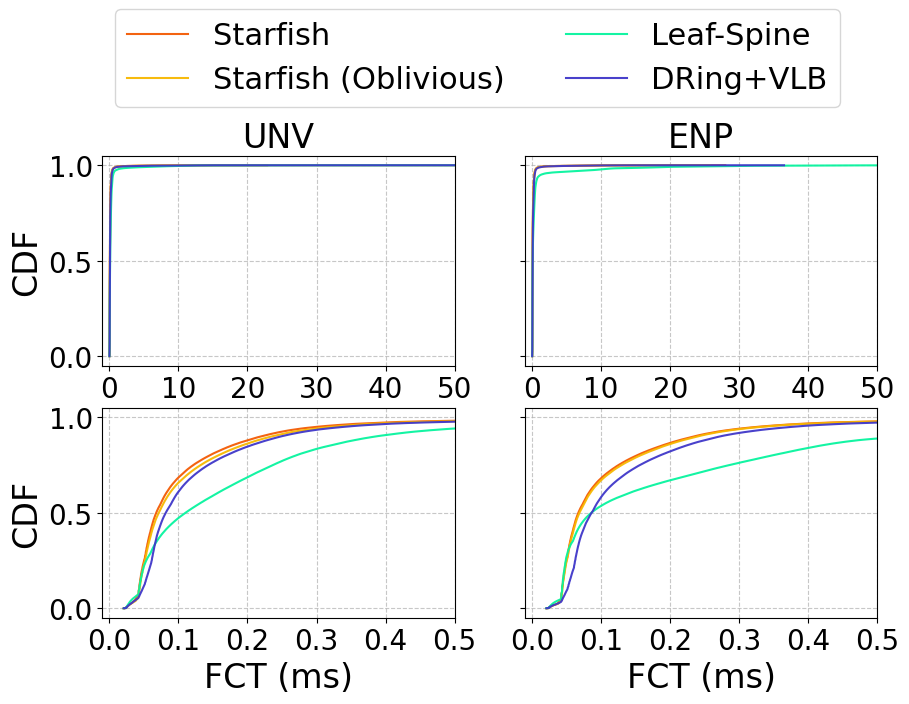

In [48]:
import matplotlib.pyplot as plt
import numpy as np

plottitledict = {"unv1":"UNV","prv1":"ENP","cluster_a":"DB","cluster_b":"WS","cluster_c":"HD"}
plotlabeldict = {"dringsu2":"Starfish","dringsu2e":"Starfish (Oblivious)","leafspine":"Leaf-Spine","df2augalg":"Dragonfly","rrgsu2":"Jellyfish","dringecmp":"DRing+ECMP","dringwcmpecmp":"DRing+WCMP","dringfatpaths":"DRing+FatPaths","dringfhi":"DRing+VLB","dringracke1four":"DRing+SMORE"}
plotcolordict = {"dringsu2":"#f35b04","dringsu2e":"#f7b801","leafspine":"#07f49e","df2augalg":"#9683ec","rrgsu2":"#5d16a6","dringecmp":"#4cc9f0","dringwcmpecmp":"#4895ef","dringfatpaths":"#4361ee","dringfhi":"#3f37c9","dringracke1four":"#3a0ca3"}


nr = 2
nc = 2
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*3),sharey='row')
for icm,cm in enumerate(["unv1","prv1"]):
    for isc,scheme in enumerate(["dringsu2","dringsu2e","leafspine","dringfhi"]):
        outfile = f"{cm}/outfiles/{scheme}_load3_seed1.out"
        # print(outfile)
        if scheme == "dringsu2e":
            durationlist = dringsu2edatadict[outfile][0] # [durationlist,sizelist,startlist]
        else:
            if cm=="unv1":
                durationlist = unv1datadict[outfile][0] # [durationlist,sizelist,startlist]
            elif cm=="prv1":
                durationlist = prv1datadict[outfile][0]
        sorted_data = np.sort(durationlist)
        cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)

        if icm==0:
            axs[0,icm].plot(sorted_data, cdf, alpha=0.95, color=plotcolordict[scheme], label=plotlabeldict[scheme])
        else:
            axs[0,icm].plot(sorted_data, cdf, alpha=0.95, color=plotcolordict[scheme])
        axs[1,icm].plot(sorted_data, cdf, alpha=0.95, color=plotcolordict[scheme])

    axs[0,icm].set_xlim(-1,50)
    axs[0,icm].set_title(f"{plottitledict[cm]}",fontsize=24)
    axs[0,icm].set_xticks([0,10,20,30,40,50])
    axs[0,icm].tick_params(axis='both', labelsize=20)
    axs[0,icm].grid(True, linestyle='--', alpha=0.7)

    axs[1,icm].set_xlim(-0.01,0.5)
    axs[1,icm].set_xlabel("FCT (ms)", fontsize=24)
    # axs[1,icm].set_title(f"{cm} (Zoomed-In)",fontsize=24)
    axs[1,icm].set_xticks([0,0.1,0.2,0.3,0.4,0.5])
    axs[1,icm].tick_params(axis='both', labelsize=20)
    axs[1,icm].grid(True, linestyle='--', alpha=0.7)

axs[0,0].set_ylabel("CDF", fontsize=24)
axs[1,0].set_ylabel("CDF", fontsize=24)
    
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=22)
plt.savefig(f"eval_main_allp.pdf", dpi=600, bbox_inches='tight')